# CME Futures: LSTM

LSTM applies gated recurrence to CME futures, testing whether sequential memory
captures carry regime transitions that static features miss. The hypothesis:
carry signals are slow-moving and mean-reverting, so an LSTM might learn to
anticipate regime switches (contango to backwardation) from the temporal
trajectory of term structure features.

**Learning Objectives**:
- Test whether LSTM's gated memory captures carry regime transitions
- Compare LSTM against the linear and GBM baselines for temporal carry modeling
- Evaluate the DL delta over the best linear baseline to determine if temporal modeling adds value
- Assess whether the 30-product cross-section provides sufficient training signal

**Book Reference**: Chapter 13, Section 13.2 (LSTM Architecture)

**Prerequisites**: [`06_linear`](06_linear.ipynb), [`07_gbm`](07_gbm.ipynb), [`08_tabular_dl`](08_tabular_dl.ipynb)

In [1]:
"""LSTM — cme_futures deep learning."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import yaml

import utils.style as style
from case_studies.utils.analytics import load_best_ic_per_family
from case_studies.utils.deep_learning import (
    _resolve_arch_name,
    create_model,
    run_dl_cv,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "cme_futures"
MODEL = "lstm"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
LOOKBACK = 60
BATCH_SIZE = 2048
MC_DROPOUT = False
MAX_FOLDS = 0

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]
    print(f"Label from setup.yaml: {PRIMARY_LABEL}")
else:
    print(f"Label override: {PRIMARY_LABEL}")

dl_config = setup.get("modeling", {}).get("dl", {})
DEVICE = dl_config.get("device", "gpu")

device_str = "cuda" if DEVICE == "gpu" and torch.cuda.is_available() else "cpu"
print(f"Case study: {CASE_STUDY_ID} | Model: {MODEL}")
print(f"Device: {device_str} | Epochs: {N_EPOCHS} | Lookback: {LOOKBACK}")

Label from setup.yaml: fwd_ret_5d
Case study: cme_futures | Model: lstm
Device: cuda | Epochs: 100 | Lookback: 60


## 1. Load Data

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "product"
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]
n_features = len(feature_names)

print(f"Dataset: {len(dataset):,} rows × {n_features} features")
print(f"Label: {label_col} | Entity: {entity_col} | Folds: {len(splits)}")

dataset_pd = dataset.to_pandas()
n_entities = dataset_pd[entity_col].nunique()
print(f"Entities: {n_entities}")

Dataset: 112,726 rows × 69 features
Label: fwd_ret_5d | Entity: product | Folds: 5
Entities: 30


## 2. Prior Baselines

Load IC results from earlier pipeline stages (Ch11 linear, Ch12 GBM)
rather than re-running them here.

In [5]:
prior_baselines = {}
_baselines = load_best_ic_per_family(["linear", "gbm"], case_studies=[CASE_STUDY_ID])
if not _baselines.is_empty():
    for row in _baselines.iter_rows(named=True):
        if row["family"] == "linear":
            prior_baselines[f"{row['config_name'].title()} (Ch11)"] = row["ic_mean"]
        elif row["family"] == "gbm":
            prior_baselines["GBM (Ch12)"] = row["ic_mean"]

if prior_baselines:
    for name, ic in prior_baselines.items():
        print(f"  {name}: IC={ic:+.4f}" if ic is not None else f"  {name}: IC=N/A")
else:
    print("  No prior results found — run 06_linear.py and 07_gbm.py first")

  GBM (Ch12): IC=+0.0252
  Enet_F0.5 (Ch11): IC=+0.0026


## 3. LSTM

Primary architecture for this notebook.

In [6]:
dl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "deep_learning")
dl_configs = [c for c in dl_configs if c["params"].get("architecture") == MODEL]

# Apply Papermill overrides to configs (test mode: fewer epochs)
for cfg in dl_configs:
    if cfg.get("n_epochs", 100) != N_EPOCHS:
        cfg["n_epochs"] = N_EPOCHS
    if cfg.get("batch_size", 2048) != BATCH_SIZE:
        cfg["batch_size"] = BATCH_SIZE
    if cfg["params"].get("lookback", 60) != LOOKBACK:
        cfg["params"]["lookback"] = LOOKBACK

print(
    f"Grid: {len(dl_configs)} configs × {dl_configs[0].get('n_epochs', 100)} epochs × {len(splits)} folds"
)
for cfg in dl_configs:
    print(
        f"  {cfg['config_name']}: {cfg['params'].get('architecture', '?')} ({cfg.get('n_epochs', 100)} epochs)"
    )

Grid: 1 configs × 100 epochs × 5 folds
  lstm_h64: lstm (100 epochs)


In [7]:
result = run_dl_cv(
    dataset_pd,
    splits,
    feature_names=feature_names,
    label_col=label_col,
    date_col=date_col,
    entity_col=entity_col,
    configs=dl_configs,
    n_features=n_features,
    device=device_str,
    save_dir=CASE_DIR / "run_log" / "training" / "deep_learning",
    register=True,
    force_retrain=FORCE_RETRAIN,
    prediction_split=PREDICTION_SPLIT,
    case_study=CASE_STUDY_ID,
    notebook=f"dl_{MODEL}",
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
)

  SKIP lstm_h64                   (complete (hash=7c6fb0661261), split=validation)
All configs already complete — nothing to do.


### Cached-checkout fallback

On a fully-registered checkout `run_dl_cv` finds every config complete, skips
training (no retrain, no registry write), and returns empty frames. Rebuild the
grid, learning curves, and fold metrics from the registered validation
predictions so the sections below render the authoritative registry numbers
(mirrors the cached path in [`08_tabular_dl`](08_tabular_dl.ipynb)).

In [8]:
if not result["grid_results"]:
    from case_studies.utils.registry import (
        build_training_spec,
        compute_fold_metrics_from_predictions,
        load_prediction_metrics,
        load_prediction_sets,
        read_predictions,
        training_hash_from_spec,
    )

    grid, curves, pred_frames = [], [], []
    for cfg in dl_configs:
        spec = build_training_spec(
            cfg["family"],
            cfg["config_name"],
            label_col,
            n_folds=len(splits),
            n_epochs=cfg.get("n_epochs"),
        )
        thash = training_hash_from_spec(spec)
        psets = load_prediction_sets(CASE_STUDY_ID, training_hash=thash, split=PREDICTION_SPLIT)
        if psets.is_empty():
            print(f"  {cfg['config_name']}: no registered {PREDICTION_SPLIT} predictions — skipped")
            continue
        cfg_curve = []
        for prow in psets.sort("checkpoint_value").iter_rows(named=True):
            m = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prow["prediction_hash"])
            ic = float(m["ic_mean"][0]) if not m.is_empty() else float("nan")
            ic_sd = (
                float(m["ic_std"][0]) if (not m.is_empty() and m["ic_std"][0] is not None) else 0.0
            )
            ep = int(prow["checkpoint_value"])
            cfg_curve.append(
                {"config": cfg["config_name"], "epoch": ep, "ic_mean": ic, "ic_std": ic_sd}
            )
            pred_frames.append(
                read_predictions(CASE_STUDY_ID, prow["prediction_hash"]).with_columns(
                    pl.lit(cfg["config_name"]).alias("config"), pl.lit(ep).alias("epoch")
                )
            )
        best_cp = max(cfg_curve, key=lambda c: c["ic_mean"])
        grid.append(
            {
                "config_name": cfg["config_name"],
                "best_epoch": best_cp["epoch"],
                "best_ic": best_cp["ic_mean"],
                "elapsed_s": 0.0,
            }
        )
        curves.extend(cfg_curve)

    grid.sort(key=lambda r: r["best_ic"], reverse=True)
    all_preds = pl.concat(pred_frames) if pred_frames else pl.DataFrame()
    best = grid[0]
    result = {
        "grid_results": grid,
        "best_config_name": best["config_name"],
        "best_epoch": best["best_epoch"],
        "best_ic": best["best_ic"],
        "predictions": (
            all_preds.filter(
                (pl.col("config") == best["config_name"]) & (pl.col("epoch") == best["best_epoch"])
            )
            if all_preds.height
            else all_preds
        ),
        "all_predictions": all_preds,
        "fold_metrics": compute_fold_metrics_from_predictions(
            all_preds,
            best["config_name"],
            best["best_epoch"],
            date_col=date_col,
            entity_col=entity_col,
        ),
        "all_learning_curves": pl.DataFrame(curves) if curves else pl.DataFrame(),
        "training_log": pl.DataFrame(),
    }
    print(
        f"Rebuilt {len(grid)} config(s) from registry (cached checkout): "
        f"best {best['config_name']} @ epoch {best['best_epoch']} IC={best['best_ic']:+.4f}"
    )

Rebuilt 1 config(s) from registry (cached checkout): best lstm_h64 @ epoch 15 IC=+0.0040


## 4. Learning Curves

In [9]:
grid_results = result["grid_results"]
best_name = result["best_config_name"]
best_epoch = result["best_epoch"]
best_ic = result["best_ic"]

curves = result["all_learning_curves"]
if curves.height > 0:
    checkpoints = sorted(curves["epoch"].unique().to_list())
    display_cps = [cp for cp in checkpoints if cp % 20 == 0 or cp == checkpoints[-1]]

    print(f"{'Config':15s}", end="")
    for cp in display_cps:
        print(f" {cp:>7d}", end="")
    print()
    print("-" * (15 + 8 * len(display_cps)))

    for r in grid_results:
        cfg_data = curves.filter(pl.col("config") == r["config_name"])
        print(f"{r['config_name']:15s}", end="")
        for cp in display_cps:
            row = cfg_data.filter(pl.col("epoch") == cp)
            cell_ic = row["ic_mean"][0] if row.height > 0 else None
            if cell_ic is not None:
                print(f" {cell_ic:+7.4f}", end="")
            else:
                print(f" {'N/A':>7s}", end="")
        print()

Config               15
-----------------------
lstm_h64        +0.0040


## 5. MC Dropout Uncertainty (Optional)

In [10]:
if MC_DROPOUT:
    from ml4t.diagnostic.metrics import cross_sectional_ic

    from case_studies.utils.deep_learning import mc_dropout_predict
    from case_studies.utils.sequence_dataset import (
        materialize_sequences,
        prepare_fold_sequence_stores,
    )

    dates_series = dataset_pd[date_col]
    last_fold = splits[-1]
    train_mask = (dates_series >= last_fold["train_start"]) & (
        dates_series <= last_fold["train_end"]
    )
    val_mask = (dates_series >= last_fold["val_start"]) & (dates_series <= last_fold["val_end"])

    train_store, val_store, _ = prepare_fold_sequence_stores(
        dataset_pd,
        train_mask=train_mask,
        val_mask=val_mask,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        lookback=LOOKBACK,
    )
    X_train_seq, y_train_seq, _, _ = materialize_sequences(train_store)
    X_val_seq, y_val_seq, val_dates, val_entities = materialize_sequences(val_store)

    if len(X_train_seq) > 0 and len(X_val_seq) > 0:
        torch_device = torch.device(device_str)
        best_cfg_dict = dl_configs[0]
        arch_name = best_cfg_dict["params"].get(
            "architecture", _resolve_arch_name(best_cfg_dict["config_name"])
        )
        from case_studies.utils.deep_learning import _build_arch_kwargs

        best_cfg = _build_arch_kwargs(
            best_cfg_dict, n_features, best_cfg_dict["params"].get("lookback", 60)
        )
        mc_model = create_model(arch_name, best_cfg).to(torch_device)

        X_t = torch.FloatTensor(X_train_seq).to(torch_device)
        y_t = torch.FloatTensor(y_train_seq).to(torch_device)
        optimizer = torch.optim.AdamW(mc_model.parameters(), lr=1e-3)
        criterion = torch.nn.MSELoss()

        mc_model.train()
        for ep in range(min(N_EPOCHS, 50)):
            idx = torch.randperm(len(X_t))
            for s in range(0, len(X_t), BATCH_SIZE):
                batch = idx[s : s + BATCH_SIZE]
                loss = criterion(mc_model(X_t[batch]), y_t[batch])
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        X_v = torch.FloatTensor(X_val_seq).to(torch_device)
        mean_pred, std_pred = mc_dropout_predict(mc_model, X_v, n_samples=50)

        median_unc = np.median(std_pred)
        low_unc = std_pred <= median_unc
        high_unc = std_pred > median_unc

        low_frame = pl.DataFrame(
            {
                "date": val_dates[low_unc],
                "symbol": val_entities[low_unc],
                "y_true": y_val_seq[low_unc],
                "y_pred": mean_pred[low_unc],
            }
        )
        ic_low = cross_sectional_ic(
            low_frame,
            low_frame,
            pred_col="y_pred",
            ret_col="y_true",
            date_col="date",
            entity_col="symbol",
            min_obs=5,
        )["ic_mean"]
        high_frame = pl.DataFrame(
            {
                "date": val_dates[high_unc],
                "symbol": val_entities[high_unc],
                "y_true": y_val_seq[high_unc],
                "y_pred": mean_pred[high_unc],
            }
        )
        ic_high = cross_sectional_ic(
            high_frame,
            high_frame,
            pred_col="y_pred",
            ret_col="y_true",
            date_col="date",
            entity_col="symbol",
            min_obs=5,
        )["ic_mean"]
        print("MC Dropout uncertainty analysis:")
        print(f"  Low uncertainty IC:  {ic_low:+.4f} ({low_unc.sum():,} samples)")
        print(f"  High uncertainty IC: {ic_high:+.4f} ({high_unc.sum():,} samples)")
        print(f"  IC gap: {ic_low - ic_high:+.4f}")

        del mc_model, X_t, y_t, X_v
        torch.cuda.empty_cache()
else:
    print("MC Dropout disabled (set MC_DROPOUT=True to enable)")

MC Dropout disabled (set MC_DROPOUT=True to enable)


## 6. Comparison

In [11]:
rows = [(name, ic) for name, ic in prior_baselines.items()]
rows.append((f"{best_name} (LSTM)", best_ic))

comparison = pl.DataFrame({"Model": [r[0] for r in rows], "IC": [r[1] for r in rows]})
comparison = comparison.with_columns(
    pl.when(pl.col("IC") == pl.col("IC").max())
    .then(pl.lit("*"))
    .otherwise(pl.lit(""))
    .alias("Best")
)
comparison

Model,IC,Best
str,f64,str
"""GBM (Ch12)""",0.025166,"""*"""
"""Enet_F0.5 (Ch11)""",0.002567,""""""
"""lstm_h64 (LSTM)""",0.00396,""""""


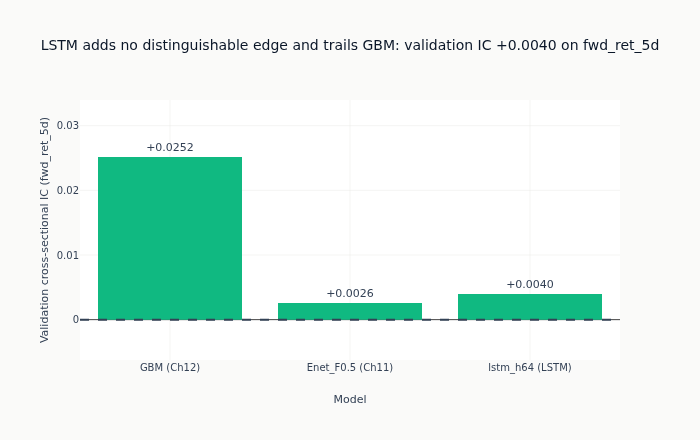

In [12]:
# Cross-family validation IC as a chart: the LSTM bar sits alongside the linear
# and GBM baselines it is meant to beat, colored by IC sign. The dashed line at
# zero is the credibility reference — none of these three intervals excludes zero
# (the HAC CIs live in 12_model_analysis); only the latent-factor SDF does.
_names = [r[0] for r in rows]
_ics = [r[1] for r in rows]
_hues = [
    style.COLORS["positive"] if (v is not None and v >= 0) else style.COLORS["negative"]
    for v in _ics
]

fig = go.Figure()
fig.add_bar(
    x=_names,
    y=_ics,
    marker_color=_hues,
    text=[f"{v:+.4f}" if v is not None else "N/A" for v in _ics],
    textposition="outside",
    cliponaxis=False,
)
fig.add_hline(y=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
fig.update_layout(
    template="ml4t",
    title=(
        f"LSTM adds no distinguishable edge and trails GBM: validation IC "
        f"{best_ic:+.4f} on {label_col}"
    ),
    xaxis_title="Model",
    yaxis_title=f"Validation cross-sectional IC ({label_col})",
    showlegend=False,
    height=440,
)
_valid = [v for v in _ics if v is not None]
_pad = max(abs(v) for v in _valid) * 0.35
fig.update_yaxes(range=[min(_valid) - _pad, max(_valid) + _pad])
fig.show()

In [13]:
# DL delta over the best linear baseline (the "(Ch11)" entry) — does temporal
# modeling add value over the linear stage?
linear_baseline = {k: v for k, v in prior_baselines.items() if k.endswith("(Ch11)")}
if linear_baseline:
    lin_name, lin_ic = next(iter(linear_baseline.items()))
    dl_delta = best_ic - lin_ic
    print(f"DL delta over {lin_name}: {dl_delta:+.4f}")
else:
    print("No linear (Ch11) baseline available for DL-delta comparison")

DL delta over Enet_F0.5 (Ch11): +0.0014


## 7. Save Results

Predictions and fold metrics are registered by `run_dl_cv()`
during training. Here we record the pipeline results JSON.

In [14]:
predictions = result["predictions"]
all_predictions = result["all_predictions"]
fold_metrics = result["fold_metrics"]

print(f"Predictions: {predictions.height:,} rows")
print(f"All predictions: {all_predictions.height:,} rows")

Predictions: 38,394 rows
All predictions: 38,394 rows


In [15]:
val_ic_mean = float(fold_metrics["ic_mean"].mean()) if fold_metrics.height > 0 else None

## 8. Key Takeaways

1. **LSTM does not clear the credibility line on `fwd_ret_5d`**: the best
   checkpoint (lstm_h64, epoch 15) reaches validation IC +0.0040 with a HAC
   95% CI of [-0.021, +0.029] ($t_{HAC}=0.31$) over ~1,290 daily observations.
   The interval straddles zero, so gated recurrence adds no distinguishable
   edge over the flat-feature baselines on this 30-product panel
   ([`12_model_analysis`](12_model_analysis.ipynb)).
2. **The weakness holds at both horizons**: on the 21-day label the same
   architecture scores IC -0.033 (HAC 95% CI [-0.075, +0.009]) — negative and
   still not distinguishable from zero. The temporal trajectory of term-structure
   features does not anticipate carry regime switches here, and the sequence
   model is not rewarded for a particular training horizon.
3. **The one credibility-line family on `fwd_ret_5d` is the latent-factor SDF**:
   IC +0.042 with a HAC 95% CI that excludes zero
   ([`12_model_analysis`](12_model_analysis.ipynb)). LSTM (+0.0040), GBM (+0.025),
   and the linear baseline sit a tier below with intervals that include zero;
   the multi-family signal concentrates in the carry-driven SDF cross-section,
   not in sequential memory.

**Next**: `10_latent_factors.py` tests whether PCA extracts sector factors.
**Book**: Section 13.7 discusses when DL adds value over simpler baselines.